In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)




In [2]:
# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = 0.5
phiS = 1.0
qK =  2.67 #ori : 1.0
phiK = phiS + np.pi/3
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5


params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [3]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    print(R,S)
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [4]:
theta, phi = get_viewing_angles(qS, phiS, 2.67, phiK)
theta, phi

[0.25903472 0.40342268 0.87758256] [-0.20833736  0.40371919 -0.89084587]


(0.8326904833428617, -1.5707963267948966)

In [5]:
theta*180/np.pi  

47.709650336254555

In [6]:
modes_l2_all = [
    (2, m, n) 
    for m in range(-2,3)
    for n in range(-55,56)
]
modes_l2_all

[(2, -2, -55),
 (2, -2, -54),
 (2, -2, -53),
 (2, -2, -52),
 (2, -2, -51),
 (2, -2, -50),
 (2, -2, -49),
 (2, -2, -48),
 (2, -2, -47),
 (2, -2, -46),
 (2, -2, -45),
 (2, -2, -44),
 (2, -2, -43),
 (2, -2, -42),
 (2, -2, -41),
 (2, -2, -40),
 (2, -2, -39),
 (2, -2, -38),
 (2, -2, -37),
 (2, -2, -36),
 (2, -2, -35),
 (2, -2, -34),
 (2, -2, -33),
 (2, -2, -32),
 (2, -2, -31),
 (2, -2, -30),
 (2, -2, -29),
 (2, -2, -28),
 (2, -2, -27),
 (2, -2, -26),
 (2, -2, -25),
 (2, -2, -24),
 (2, -2, -23),
 (2, -2, -22),
 (2, -2, -21),
 (2, -2, -20),
 (2, -2, -19),
 (2, -2, -18),
 (2, -2, -17),
 (2, -2, -16),
 (2, -2, -15),
 (2, -2, -14),
 (2, -2, -13),
 (2, -2, -12),
 (2, -2, -11),
 (2, -2, -10),
 (2, -2, -9),
 (2, -2, -8),
 (2, -2, -7),
 (2, -2, -6),
 (2, -2, -5),
 (2, -2, -4),
 (2, -2, -3),
 (2, -2, -2),
 (2, -2, -1),
 (2, -2, 0),
 (2, -2, 1),
 (2, -2, 2),
 (2, -2, 3),
 (2, -2, 4),
 (2, -2, 5),
 (2, -2, 6),
 (2, -2, 7),
 (2, -2, 8),
 (2, -2, 9),
 (2, -2, 10),
 (2, -2, 11),
 (2, -2, 12),
 (2, -2, 13)

In [7]:
print("Generating waveform...")
# 
h = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2_all, include_minus_mkn=False)

Generating waveform...


(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


In [8]:
h

array([-2.14875615e-22+3.94971349e-22j, -1.62037814e-22+4.13513145e-22j,
       -1.10292500e-22+4.24297884e-22j, ...,
       -5.57523216e-22-2.32625449e-22j, -5.83990946e-22-9.39245834e-23j,
       -5.78338612e-22+5.11309173e-23j])

In [9]:
h_real = h.real
h_real

array([-2.14875615e-22, -1.62037814e-22, -1.10292500e-22, ...,
       -5.57523216e-22, -5.83990946e-22, -5.78338612e-22])

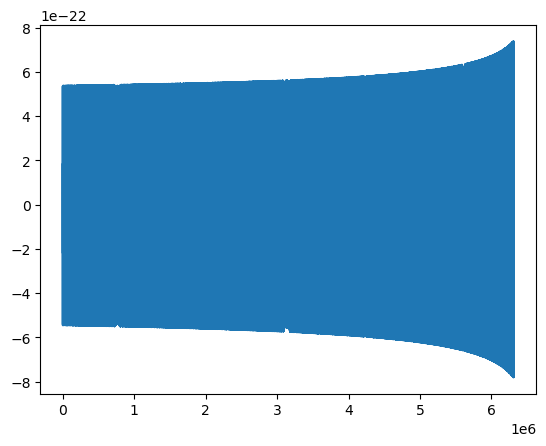

In [10]:
plt.plot(h_real.get())
plt.show()

In [11]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)
gwf.rhostat(h)

array(64.23006724)

In [12]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [13]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [14]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


11.606899362022393

In [15]:
p_arr, e_arr

(array([11.7       , 11.69999959, 11.69999917, ...,  5.62159697,
         5.62159237,  5.62158778]),
 array([0.4       , 0.39999998, 0.39999996, ..., 0.12687824, 0.12687808,
        0.12687792]))

In [16]:
len(p_arr)

6311629

In [17]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.01971368776220821, 0.019108341687235263, 0.015451845941009939],
 [0.019713689337112185, 0.019108343183883658, 0.01545184703159573],
 [0.019713690912014286, 0.019108344680520625, 0.015451848122172113],
 [0.019713692486921473, 0.019108346177170728, 0.015451849212759373],
 [0.019713694061824667, 0.01910834767382069, 0.015451850303346351],
 [0.019713695636715104, 0.01910834917045682, 0.01545185139392199],
 [0.01971369721163589, 0.019108350667113083, 0.015451852484513974],
 [0.019713698786543627, 0.019108352163756902, 0.015451853575095858],
 [0.019713700361440087, 0.01910835366039379, 0.01545185466567214],
 [0.01971370193633806, 0.019108355157038372, 0.015451855756254467],
 [0.01971370351124129, 0.019108356653691774, 0.015451856846843819],
 [0.019713705086149946, 0.019108358150337634, 0.015451857937427298],
 [0.01971370666105235, 0.01910835964698086, 0.015451859028008398],
 [0.01971370823597391, 0.01910836114363829, 0.015451860118600969],
 [0.019713709810886857, 0.019108362640287625, 0.

In [18]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [19]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-1,6)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [20]:
modes_21 = [
    (2, m, 1) 
    for m in range(-2,3)
]
modes_21

[(2, -2, 1), (2, -1, 1), (2, 0, 1), (2, 1, 1), (2, 2, 1)]

In [21]:
len(modes), len(mode_freqs)

(84, 84)

In [22]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1,6)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-1,6)
]

mode_freqs_l2 = []
for l, m, n in modes_l2:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l2.append(f_mode)

mode_freqs_l3 = []
for l, m, n in modes_l3:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l3.append(f_mode)

In [23]:
mode_freqs_21 = []
for l, m, n in modes_21:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_21.append(f_mode)

In [24]:
mode_freqs_21

[array([-0.00077469, -0.00077469, -0.00077469, ..., -0.00328799,
        -0.00328799, -0.003288  ]),
 array([-0.00013771, -0.00013771, -0.00013771, ..., -0.00101654,
        -0.00101655, -0.00101655]),
 array([0.00049927, 0.00049927, 0.00049927, ..., 0.0012549 , 0.0012549 ,
        0.0012549 ]),
 array([0.00113625, 0.00113625, 0.00113625, ..., 0.00352634, 0.00352635,
        0.00352635]),
 array([0.00177323, 0.00177323, 0.00177323, ..., 0.00579779, 0.0057978 ,
        0.0057978 ])]

In [25]:
sum_freqs = np.zeros(6311629,)
for i in range(-2,3):
    print(i)
    sum_freqs += mode_freqs_21[i]

-2
-1
0
1
2


In [26]:
sum_freqs

array([0.00249636, 0.00249636, 0.00249636, ..., 0.0062745 , 0.0062745 ,
       0.00627451])

In [27]:
5*freq_r

array([0.00249636, 0.00249636, 0.00249636, ..., 0.0062745 , 0.0062745 ,
       0.00627451])

In [28]:
import scipy 
fs = 1.0 / dt  # Sampling frequency
nperseg = 2**16  # Window size for STFT
noverlap = nperseg * 3 // 4

f, t, Zxx = signal.stft(h_real.get(), fs=fs, 
                               nperseg=nperseg, noverlap=noverlap, 
                               return_onesided=True) #NOTE: set True

# Zxx = scipy.fft.fftshift(Zxx, axes=0)
# f = scipy.fft.fftshift(f)

# t_years = t / YRSID_SI
# T_total = len(h_real) * dt / YRSID_SI
# t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

t_traj_years = t_arr - t_arr[0] 

log_amp = np.log10(np.abs(Zxx))
max_val = np.max(log_amp)
# NOTE: change ord of magnitude
vmin_val = max_val - 6
t_spec_seconds = t - t[0] 

extent = [t_spec_seconds[0], t_spec_seconds[-1], f[0], f[-1]]

In [29]:
log_amp

array([[-25.06303092, -25.36397714, -31.57592464, ..., -26.17474551,
        -25.69652724, -25.85046256],
       [-25.06303274, -25.36397813, -31.56573813, ..., -26.17474499,
        -25.69652672, -25.85046218],
       [-25.06303402, -25.36398066, -31.53767338, ..., -26.1747433 ,
        -25.69652471, -25.85046034],
       ...,
       [-26.43366064, -26.73470916, -36.9959924 , ..., -26.55439431,
        -26.07708239, -26.23164183],
       [-26.43366064, -26.73470916, -36.85173377, ..., -26.55439433,
        -26.07708239, -26.23164183],
       [-26.43366064, -26.73470916, -36.68616507, ..., -26.55439431,
        -26.07708239, -26.23164183]])

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4066895820.py:11: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")


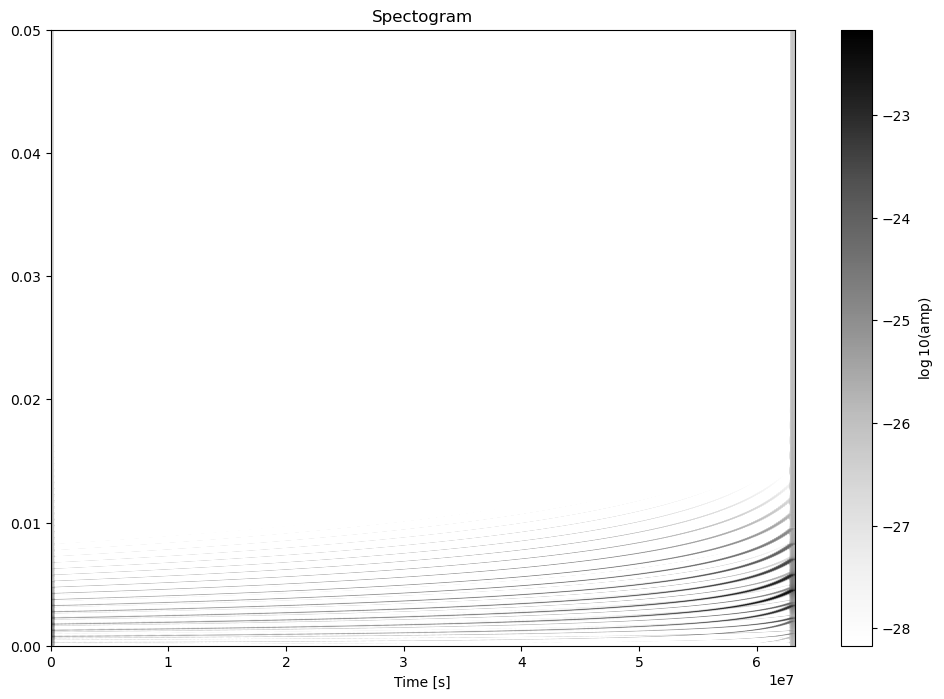

In [46]:
# STFT amplitudes only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)
cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")
plt.xlabel('Time [s]')
plt.title('Spectogram')
plt.show()

In [47]:
from collections import defaultdict

# sum frequencies for each (l, n)
mode_groups = defaultdict(list)
for i, (ell, m, n) in enumerate(modes):
    mode_groups[(ell, n)].append(mode_freqs[i])
summed_freqs = {}
for (ell, n), freq_list in mode_groups.items():
    summed_freqs[(ell, n)] = np.sum(freq_list, axis=0)


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3809841431.py:44: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3809841431.py:48: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3809841431.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


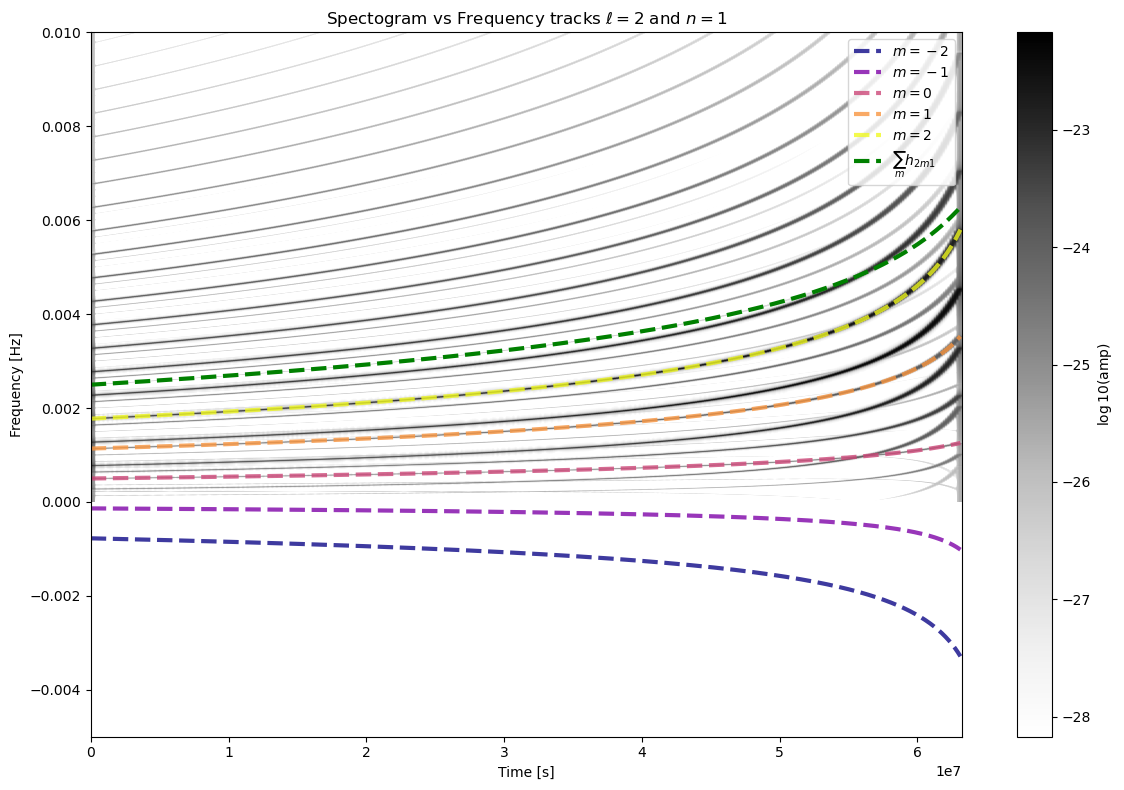

In [48]:
import matplotlib.cm as cm

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)

m_values = np.arange(-2, 3) 
cmap = cm.get_cmap('plasma') 
colors = cmap(np.linspace(0, 1, len(m_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$m={m}$'
    if ell == 2 and n == 1:
        color_idx = m + 2  # Map m to color index
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)


# # plot each m for (ell=2,n=1)
# for i in range(len(modes)):
#     ell, m, n = modes[i]
#     col = 'red'
#     lstyle = 'dashed'
#     linewidth=3
#     label = f'$m={m}$'
#     if ell==2 and n==1:
#         plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=col,linewidth=linewidth, alpha=0.8, label=label)
# plot summed freqs for (ell=2, n=1)
# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = r'$\sum_m h_{2m1}$'
    if ell == 2 and n==1:
        plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/2139546465.py:14: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/2139546465.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


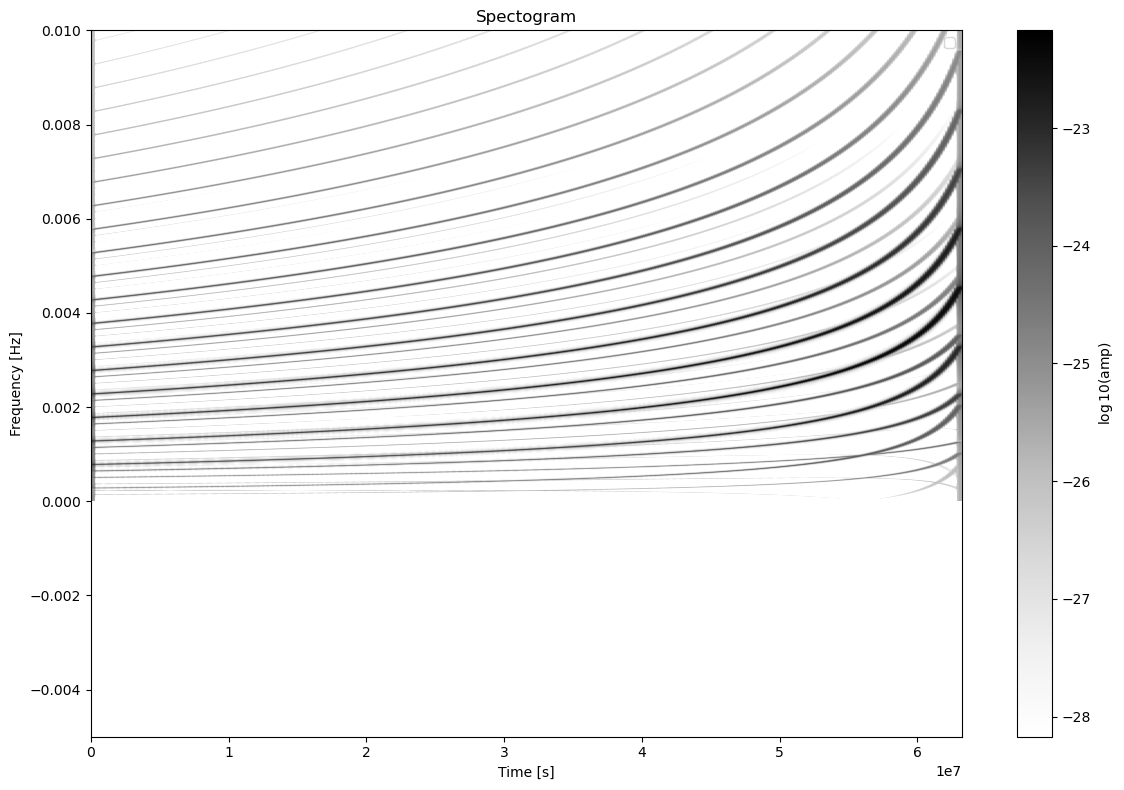

In [49]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/2120802289.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/2120802289.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=2$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/2120802289.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter')


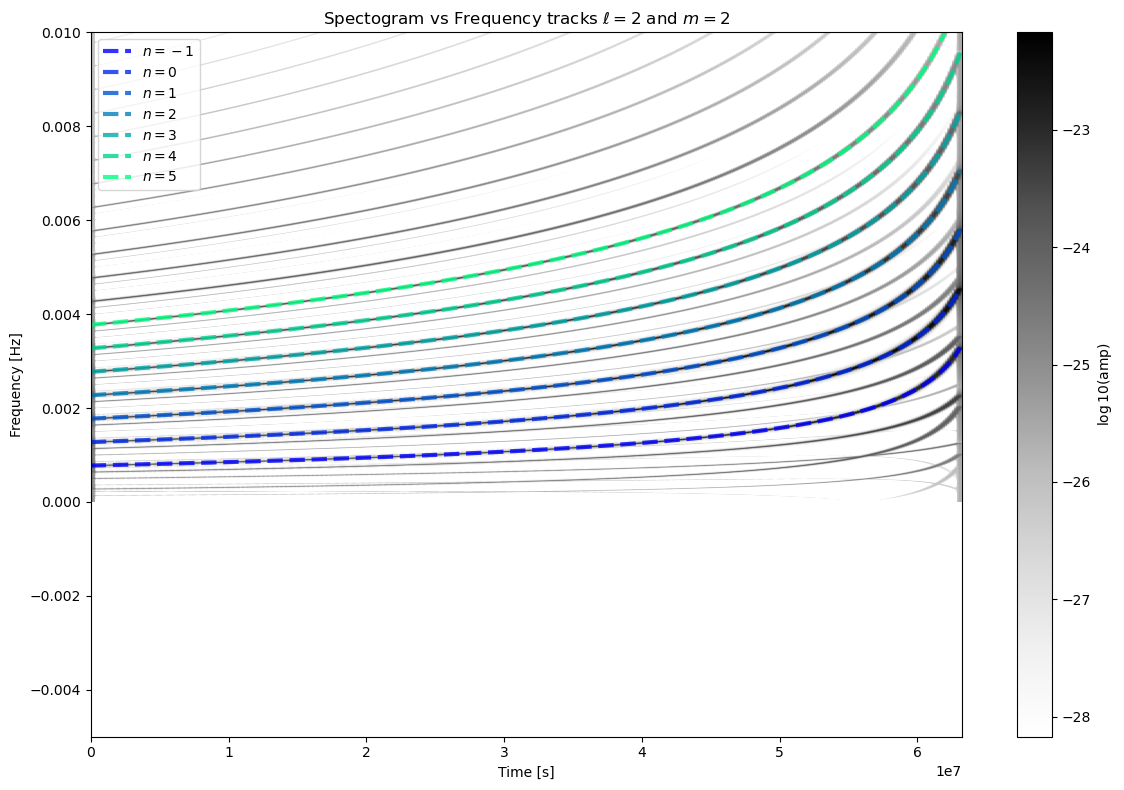

In [50]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('winter') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 2:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=2$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/314335290.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/314335290.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=1$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/314335290.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


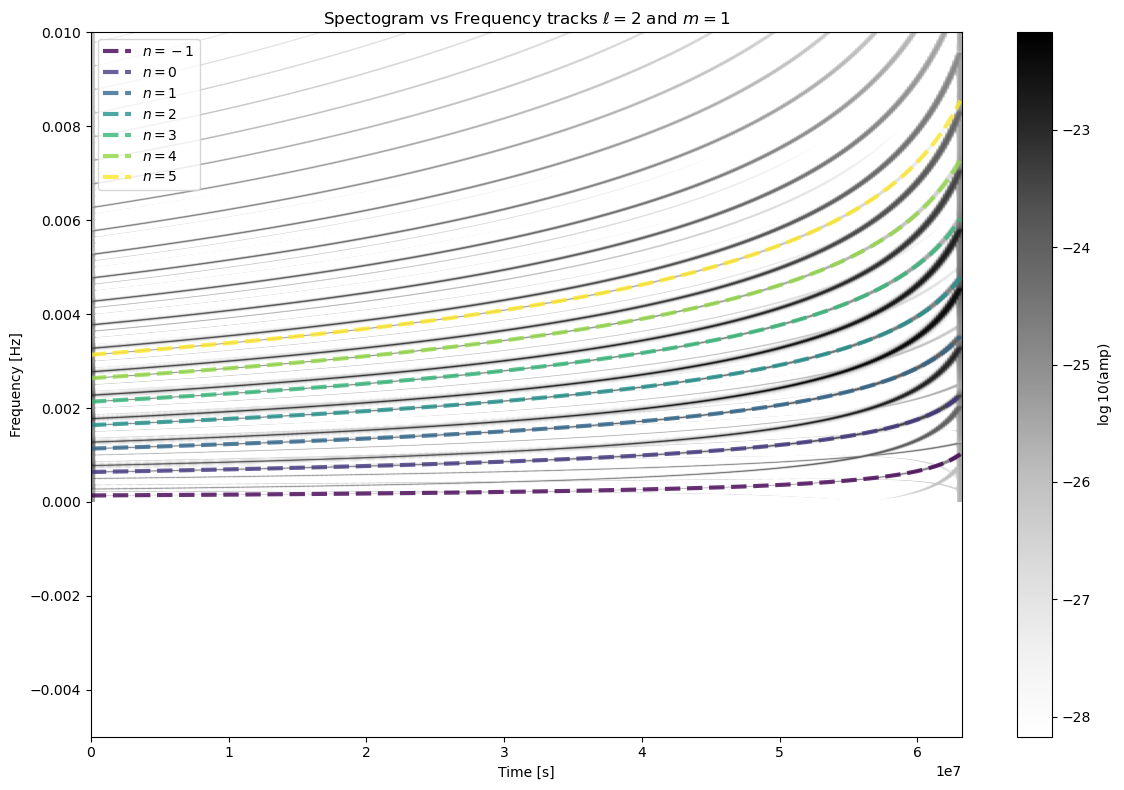

In [51]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('viridis') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 1:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=1$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3790677791.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3790677791.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=0$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3790677791.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter')


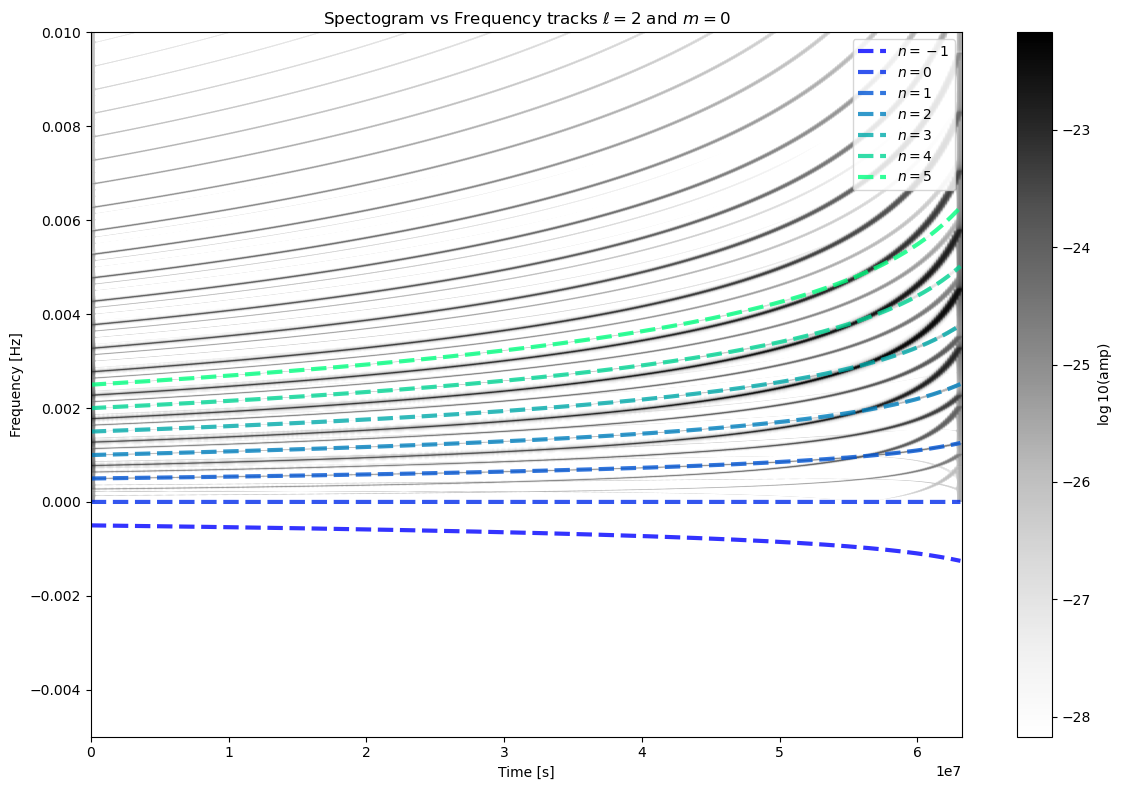

In [53]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('winter') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 0:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=0$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3732593438.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3732593438.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=-2$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/3732593438.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter')


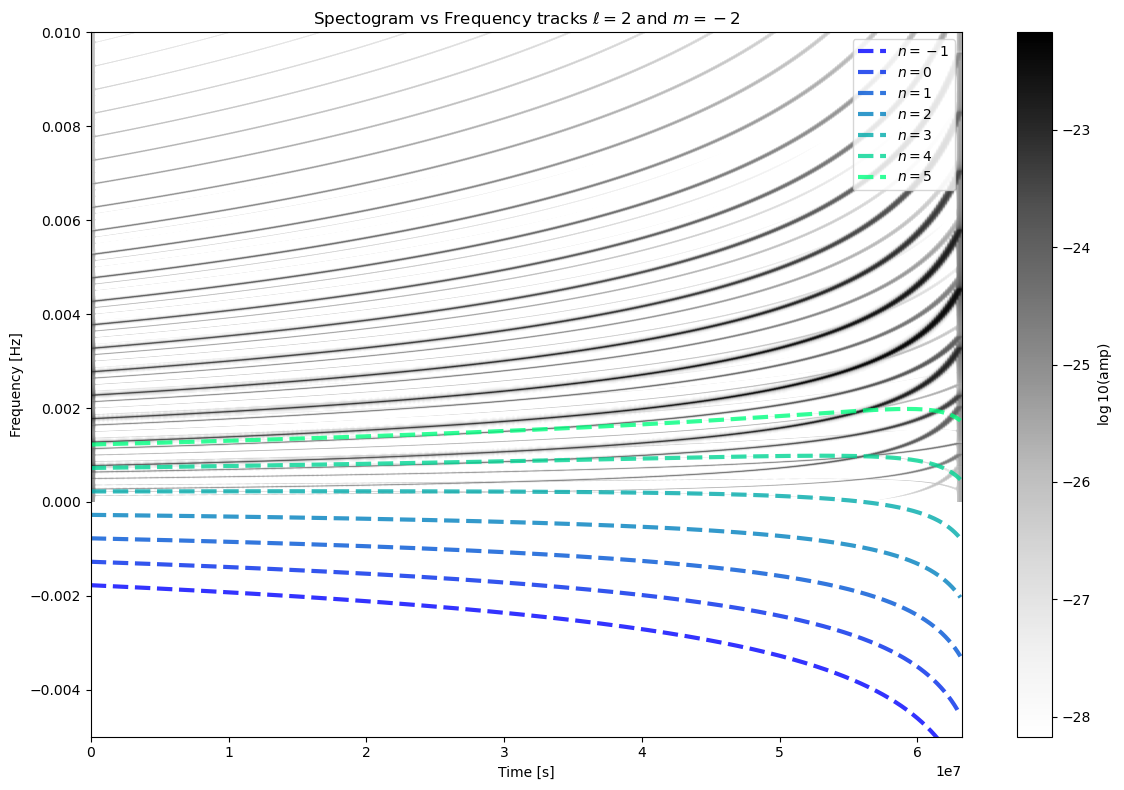

In [54]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('winter') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == -2:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=-2$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4133141058.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4133141058.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4133141058.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('summer')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4133141058.py:43: UserWarning: Creating legend with loc="best" can 

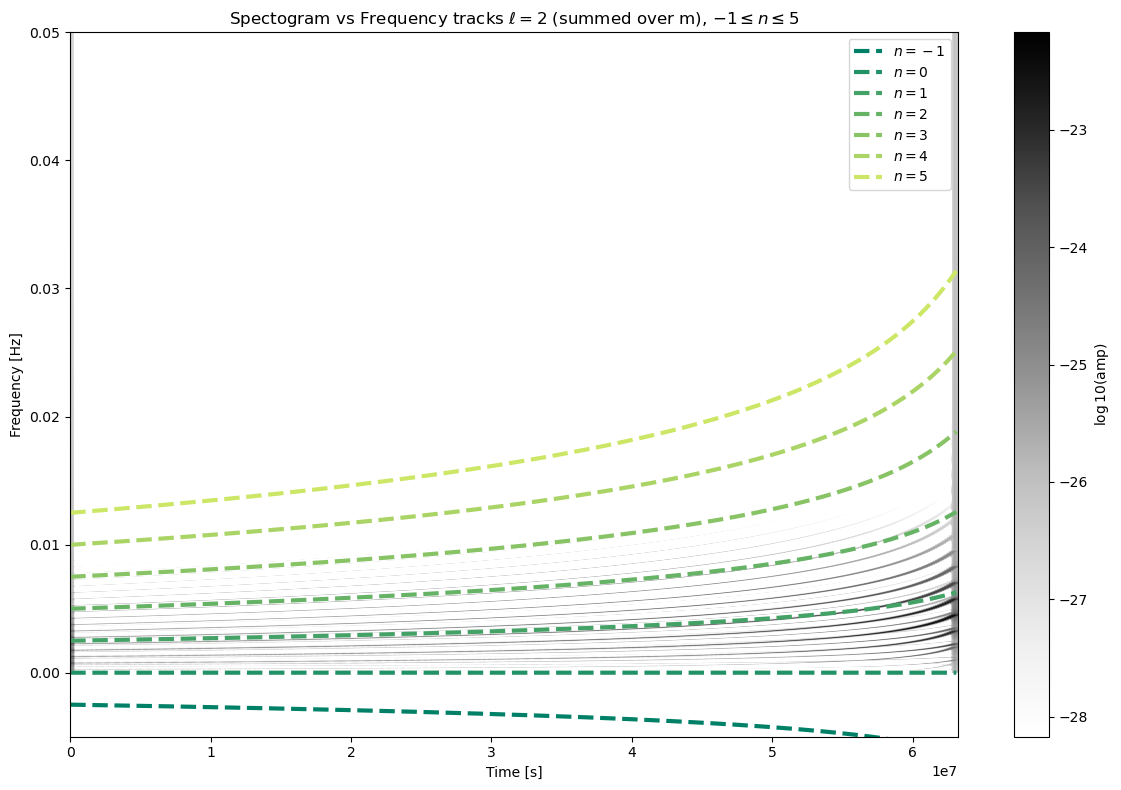

In [59]:

# Spectogram only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# plot summed freqs

n_values_summed = list(set(n for (ell, n) in summed_freqs.keys()))  
n_values_summed.sort()
cmap = cm.get_cmap('summer') 
colors_summed = cmap(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 2:
        color_idx = n_values_summed.index(n)
        plt.plot(t_traj_years, freq, color=colors_summed[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2:
#         plt.plot(t_traj_years, freq, color='red', linewidth=1, linestyle='dashed', alpha=1, label=label)


cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
# plt.ylim(None,0.04)
plt.ylim(-0.005, 0.05)

plt.legend()
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/889400627.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/889400627.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/889400627.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('autumn')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/889400627.py:43: UserWarning: Creating legend with loc="best" can be s

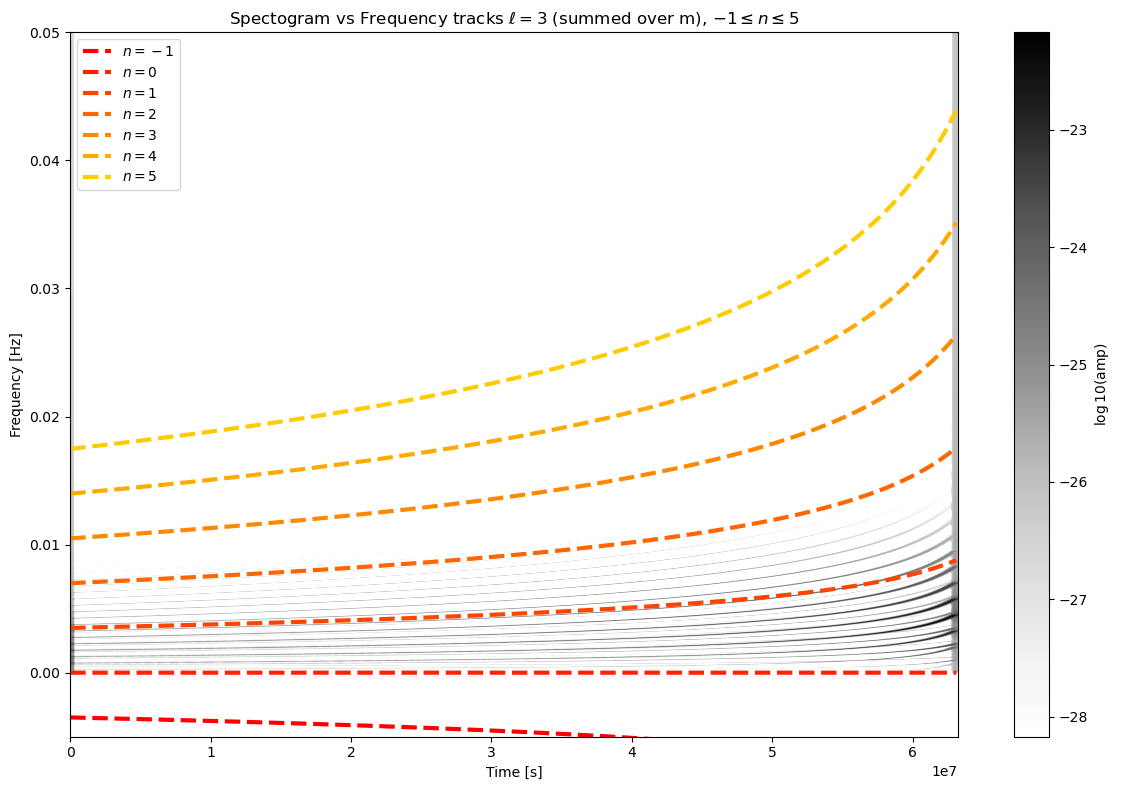

In [60]:

# Spectogram only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# plot summed freqs

n_values_summed = list(set(n for (ell, n) in summed_freqs.keys()))  
n_values_summed.sort()
cmap = cm.get_cmap('autumn') 
colors_summed = cmap(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 3:
        color_idx = n_values_summed.index(n)
        plt.plot(t_traj_years, freq, color=colors_summed[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2:
#         plt.plot(t_traj_years, freq, color='red', linewidth=1, linestyle='dashed', alpha=1, label=label)


cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
# plt.ylim(None,0.04)
plt.ylim(-0.005, 0.05)

plt.legend()
plt.tight_layout()
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\l'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/346339980.py:29: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_title('Spectrogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/346339980.py:49: SyntaxWarning: invalid escape sequence '\e'
  ax3.set_title('Spectrogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/346339980.py:55: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/346339980.py:18: MatplotlibDeprecationWarning: The get_cmap function was dep

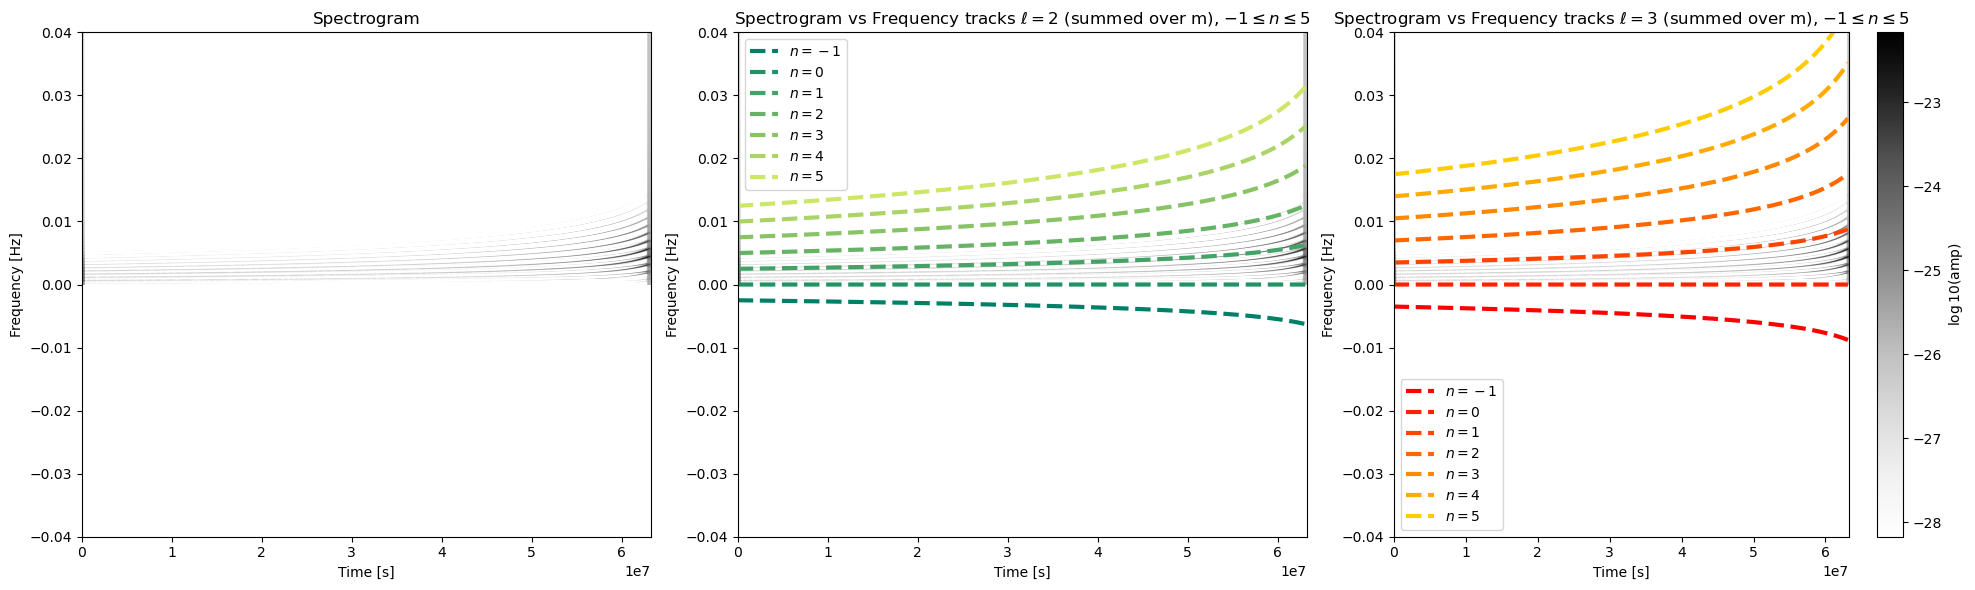

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Subplot 1: STFT amplitudes only
ax1 = axes[0]
im = ax1.imshow(log_amp, aspect='auto', origin='lower', extent=extent, 
                 cmap='Greys', vmin=vmin_val, vmax=max_val)
ax1.set_ylim(-0.04, 0.04)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Frequency [Hz]')
ax1.set_title('Spectrogram')

# Subplot 2: ell=2 (summed over m)
ax2 = axes[1]
ax2.imshow(log_amp, aspect='auto', origin='lower', extent=extent, 
           cmap='Greys', vmin=vmin_val, vmax=max_val)

n_values_summed = list(set(n for (ell, n) in summed_freqs.keys()))  
n_values_summed.sort()
cmap_summer = cm.get_cmap('summer') 
colors_summer = cmap_summer(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 2:
        color_idx = n_values_summed.index(n)
        ax2.plot(t_traj_years, freq, color=colors_summer[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

ax2.set_ylabel('Frequency [Hz]')
ax2.set_xlabel('Time [s]')
ax2.set_title('Spectrogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
ax2.set_ylim(-0.04, 0.04)
ax2.legend()

# Subplot 3: ell=3 (summed over m)
ax3 = axes[2]
ax3.imshow(log_amp, aspect='auto', origin='lower', extent=extent, 
           cmap='Greys', vmin=vmin_val, vmax=max_val)

cmap_autumn = cm.get_cmap('autumn') 
colors_autumn = cmap_autumn(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 3:
        color_idx = n_values_summed.index(n)
        ax3.plot(t_traj_years, freq, color=colors_autumn[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

ax3.set_ylabel('Frequency [Hz]')
ax3.set_xlabel('Time [s]')
ax3.set_title('Spectrogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
ax3.set_ylim(-0.04, 0.04)
ax3.legend()

# Single colorbar for all subplots
cbar = fig.colorbar(im, ax=ax3)
cbar.set_label(f"$\log10$(amp)")

plt.tight_layout()
plt.show()

In [63]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

In [64]:
nperseg

65536

In [65]:
nperseg = 2**16  
noverlap = nperseg * 3 // 4  # 

# nperseg = 2**14
# noverlap = nperseg // 2
f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get().real, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get().real, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')



In [66]:
Zxx_l2

array([[ 8.50330843e-26+0.00000000e+00j,  4.25265770e-26+0.00000000e+00j,
        -4.74664150e-32+0.00000000e+00j, ...,
        -5.76928952e-27+0.00000000e+00j, -1.73585360e-26+0.00000000e+00j,
        -1.21813767e-26+0.00000000e+00j],
       [-8.50326906e-26+2.00829423e-29j, -1.01642488e-29-4.25264823e-26j,
        -4.75627860e-32-5.23048635e-33j, ...,
        -2.06085747e-27-5.38866137e-27j,  1.62133427e-26-6.20058594e-27j,
         4.35122530e-27+1.13777483e-26j],
       [ 8.50325051e-26-4.01503023e-29j, -4.25262433e-26+2.03705704e-29j,
        -4.78523922e-32-1.04729729e-32j, ...,
         4.29700065e-27-3.84979574e-27j, -1.29288682e-26+1.15830775e-26j,
         9.07289470e-27-8.12837804e-27j],
       ...,
       [-4.10604539e-27+3.54036060e-31j,  2.05293418e-27-1.77020010e-31j,
        -7.53211553e-39-1.99972587e-38j, ...,
        -2.11207896e-27-1.87735913e-27j,  6.33901851e-27+5.63454969e-27j,
        -4.44081355e-27-3.94729631e-27j],
       [ 4.10604538e-27-1.77018040e-31j, -8.

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4165307623.py:10: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
/var/tmp/pbs.555123.stdct-mgmt-02/ipykernel_3985868/4165307623.py:10: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$

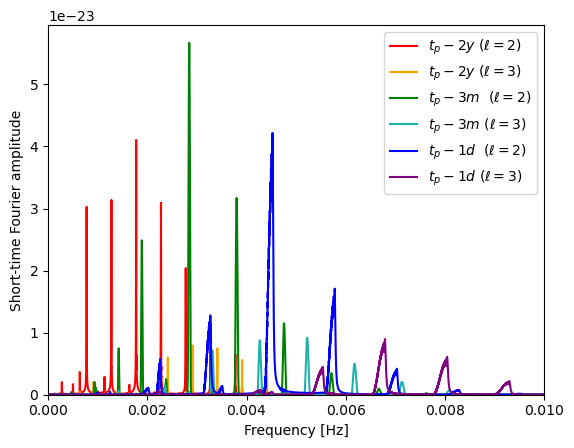

In [68]:
T_total_seconds = len(h_l2.get()) * dt  

times_seconds = [
    0,                           # Start of signal
    T_total_seconds - 3*30*86400,  # 3 months before
    T_total_seconds - 86400        # 1 day before end
]
colors_l2 = ['red', 'green', 'blue']
colors_l3 = ['orange', 'lightseagreen', 'purple']
labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
labels_l3 = ['$t_p - 2y$ ($\ell=3$)', '$t_p - 3m$ ($\ell=3$)', '$t_p - 1d$ ($\ell=3$)']

fig, ax = plt.subplots()

for time_s, color_l2, color_l3, label_l2, label_l3 in zip(times_seconds, colors_l2, colors_l3, labels_l2, labels_l3):
    # Find closest index
    idx = np.argmin(np.abs(t_spec_seconds - time_s))
    # amplitude = np.sqrt(Sxx[:, idx])
    amplitude_l2 = np.abs(Zxx_l2[:, idx]) 
    amplitude_l3 = np.abs(Zxx_l3[:, idx])  

    ax.plot(f_l2, amplitude_l2, color=color_l2, label=label_l2, linewidth=1.5)
    ax.plot(f_l3, amplitude_l3, color=color_l3, label=label_l3, linewidth=1.5)


ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Short-time Fourier amplitude')
ax.set_xlim([0, 0.01])
ax.set_ylim([0, None]) 
ax.legend()

In [69]:
T,dt

(2.0, 10.0)

In [76]:
h_full = waveform_gen(*params, T=T, dt=dt)

In [77]:
snr_full = gwf.rhostat(h_full)
snr_full

array(72.31453248)

In [78]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(64.15024017)

In [79]:
p_l2 = gwf.rhostat(h_l2)**2/gwf.rhostat(h_full)**2 * 100
p_l2

array(78.69468616)

In [80]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(30.3467549)

In [81]:
p_l3 = gwf.rhostat(h_l3)**2 /gwf.rhostat(h_full)**2 *100
p_l3

array(17.61056738)

In [82]:
p_l2+p_l3

array(96.30525354)